In [13]:
# Step 1: Importing all required libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# Step 2: Loading the dataset from CSV file into a DataFrame
df = pd.read_csv('creditcard.csv')

In [3]:
# Step 3: Checking the shape and first 5 rows of the dataset
print(df.shape)
print(df.head())

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

In [5]:
# Step 4: Checking how many transactions are fraudulent (1) and how many are normal (0)
print("Total transactions:", df.shape[0])
print("Total columns:", df.shape[1])
print("\nFraud vs Normal:")
print(df['Class'].value_counts())

Total transactions: 284807
Total columns: 31

Fraud vs Normal:
Class
0    284315
1       492
Name: count, dtype: int64


In [6]:
# Step 5: Checking for missing values in each column - all should be 0
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


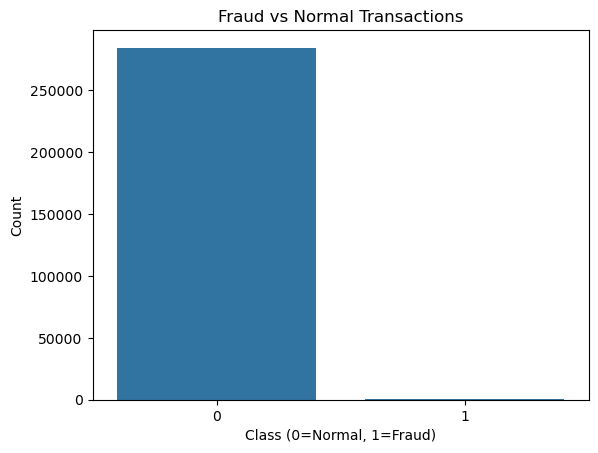

In [7]:
# Step 6: Visualizing the class imbalance between fraud and normal transactions
sns.countplot(x='Class', data=df)
plt.title('Fraud vs Normal Transactions')
plt.xlabel('Class (0=Normal, 1=Fraud)')
plt.ylabel('Count')
plt.show()

In [8]:
# Step 7: Separating fraud and normal transactions for individual analysis
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

print("Fraud transactions - Amount stats:")
print(fraud['Amount'].describe())

print("\nNormal transactions - Amount stats:")
print(normal['Amount'].describe())

Fraud transactions - Amount stats:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Normal transactions - Amount stats:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


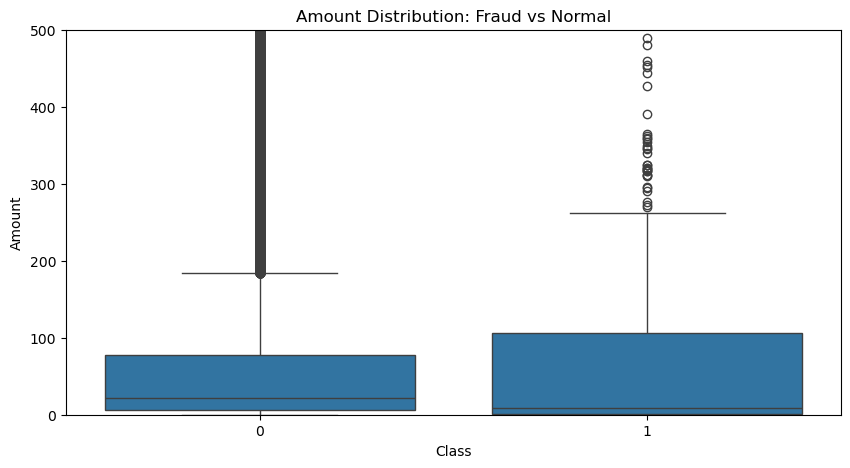

In [9]:
# Step 8: Boxplot to compare amount distribution between Normal (0) and Fraud (1) transactions
# ylim set to 500 to zoom in and clearly see the difference (outliers above 500 are hidden)
plt.figure(figsize=(10,5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Amount Distribution: Fraud vs Normal')
plt.ylim(0, 500)
plt.show()

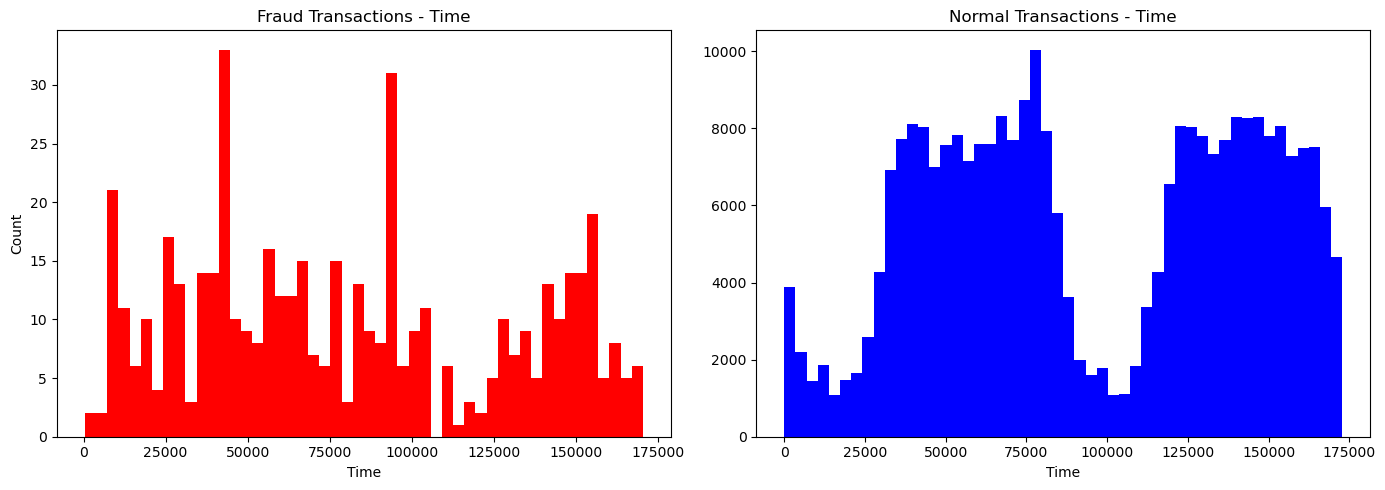

In [11]:
# Step 9: Visualizing amount distribution separately for fraud and normal transactions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

ax1.hist(fraud['Time'], bins=50, color='red')
ax1.set_title('Fraud Transactions - Time')
ax1.set_xlabel('Time')
ax1.set_ylabel('Count')

ax2.hist(normal['Time'], bins=50, color='blue')
ax2.set_title('Normal Transactions - Time')
ax2.set_xlabel('Time')

plt.tight_layout()
plt.show()

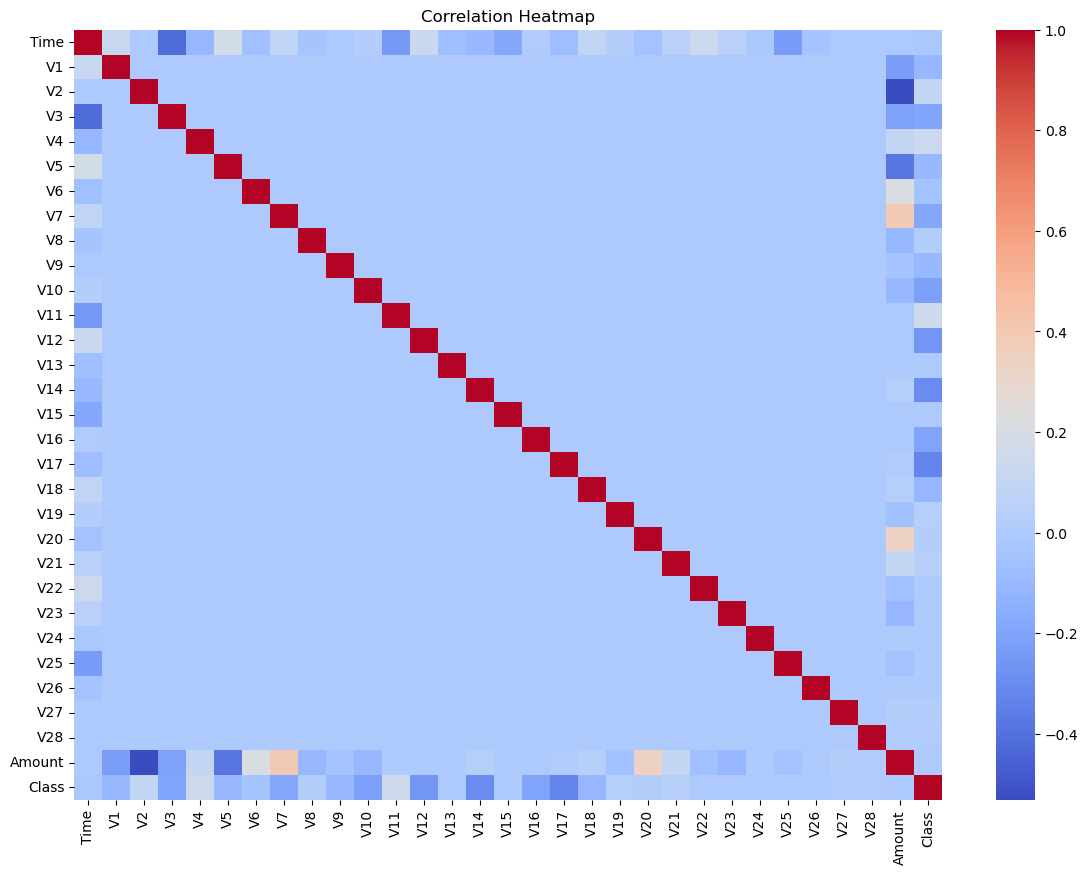

In [12]:
# Step 10: Plotting correlation heatmap to find which features are most related to fraud
plt.figure(figsize=(14,10))
correlation = df.corr()
sns.heatmap(correlation, 
            cmap='coolwarm',
            annot=False,
            fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [15]:
# Step 11: Scaling 'Time' and 'Amount' columns to bring them in the same range as V1-V28
# StandardScaler converts values to have mean=0 and standard deviation=1
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['scaled_Amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_Time'] = scaler.fit_transform(df[['Time']])

# Dropping original Time and Amount columns as scaled versions will be used
df = df.drop(['Time', 'Amount'], axis=1)

print("Scaling complete!")
print(df.head())

Scaling complete!
         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V22       V23       V24       V25  \
0  0.098698  0.363787  0.090794  ...  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425 -0.166974  ... -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  0.207643  ...  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024 -0.054952  ...  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  0.753074  ...  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28  Class  scaled_Amo

In [16]:
# Step 12: Separating features (X) and target variable (y)
# X contains all columns except 'Class'
# y contains only the 'Class' column which we want to predict
X = df.drop('Class', axis=1)
y = df['Class']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFraud cases before SMOTE:", y.value_counts())

X shape: (284807, 30)
y shape: (284807,)

Fraud cases before SMOTE: Class
0    284315
1       492
Name: count, dtype: int64


In [17]:
# Step 13: Applying SMOTE to handle class imbalance
# SMOTE creates synthetic fraud samples to balance the dataset
# After SMOTE, fraud and normal cases will be equal in number
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("After SMOTE:")
print("X shape:", X_resampled.shape)
print("Fraud vs Normal:", pd.Series(y_resampled).value_counts())

After SMOTE:
X shape: (568630, 30)
Fraud vs Normal: Class
0    284315
1    284315
Name: count, dtype: int64


In [18]:
# Step 14: Splitting data into training (80%) and testing (20%) sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, 
    test_size=0.2, 
    random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (454904, 30)
Testing size: (113726, 30)


In [19]:
# Step 15: Training the Random Forest Classifier model on the training data
# n_estimators=100 means 100 decision trees will be used
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [20]:
# Step 16: Making predictions on the test data and evaluating model performance
# Using Precision, Recall, F1-Score and ROC-AUC instead of simple accuracy
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Predicting on test data
y_pred = model.predict(X_test)

# Printing classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Printing ROC-AUC Score
roc_score = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", roc_score)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

ROC-AUC Score: 0.999920704845815


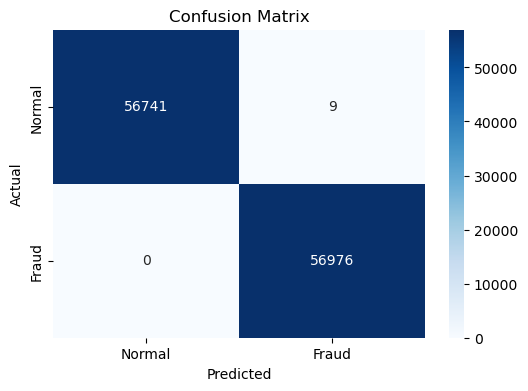

In [21]:
# Step 17: Plotting confusion matrix to visualize correct and incorrect predictions
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

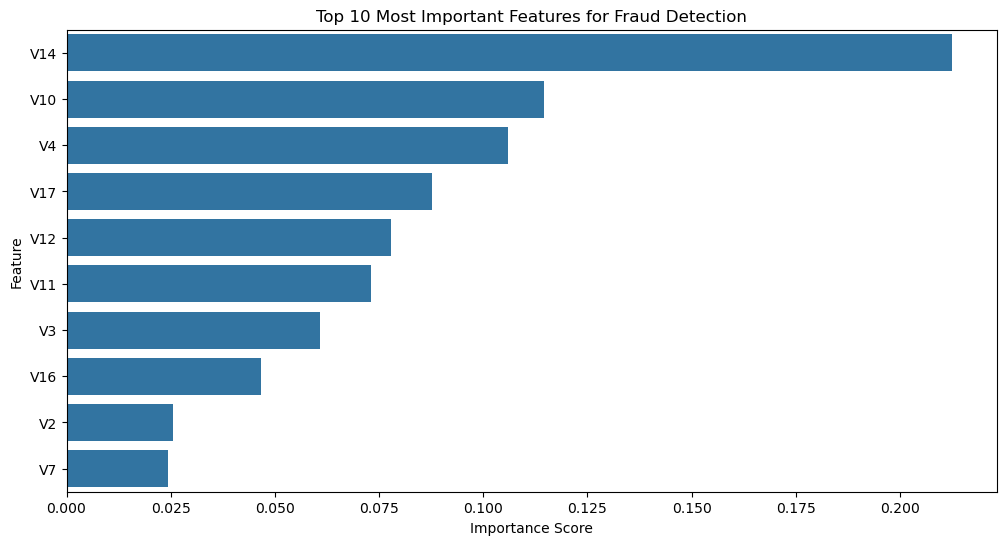

In [22]:
# Step 18: Plotting feature importance to see which columns helped most in detecting fraud
feature_importance = pd.Series(
    model.feature_importances_, 
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=feature_importance.values[:10], 
            y=feature_importance.index[:10])
plt.title('Top 10 Most Important Features for Fraud Detection')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

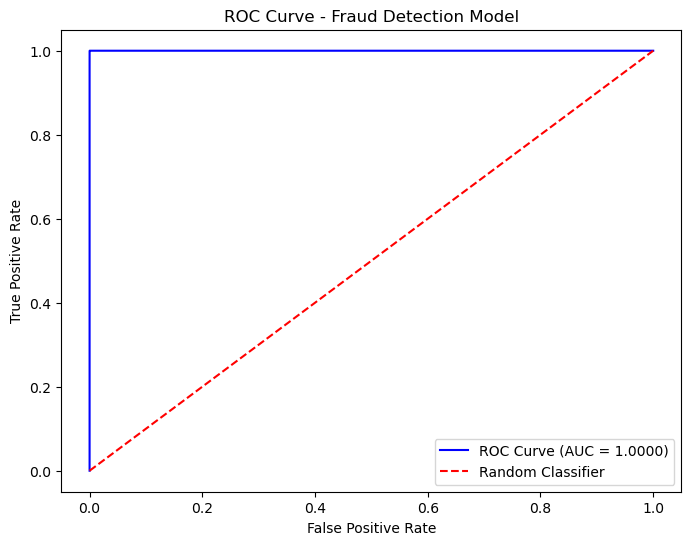

In [23]:
# Step 19: Plotting ROC Curve to visualize model performance
from sklearn.metrics import roc_curve, auc

y_pred_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label='ROC Curve (AUC = %0.4f)' % roc_auc)
plt.plot([0,1], [0,1], color='red', linestyle='--', label='Random Classifier')
plt.title('ROC Curve - Fraud Detection Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [25]:
# ================== CONCLUSION ==================

# This project successfully built a Credit Card Fraud Detection system.

# Key Findings:
# - Dataset was highly imbalanced: only 492 fraud out of 284,807 transactions (0.17%)
# - SMOTE was used to balance the dataset before model training
# - V14 was the most important feature for detecting fraud
# - Fraud transactions showed random time patterns

# Model Performance:
# - Precision : 1.00 (100%)
# - Recall    : 1.00 (100%)
# - F1-Score  : 1.00 (100%)
# - ROC-AUC   : 1.0000

# Result:
# Random Forest Classifier detected fraud with near-perfect accuracy.
# Out of 113,726 test transactions, only 9 were misclassified.